<h1><font>Data Preprocessing & Feature Engineering</font></h1>
<h2>Student Exam Performance Dataset</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [2]:
# Load the dataset
# Source from kaggle https://www.kaggle.com/datasets/ssssws/student-exam-performance-dataset
df = pd.read_csv('../dataset/student_exam_performance_dataset.csv')
print(f"Original dataset shape: {df.shape}")
df.head()

Original dataset shape: (10000, 23)


,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
0,S00001,Male,17,High School,Medium,Yes,Quiet,2.98,96.5,6.05,0.1,80.5,68.7,1,Yes,42.8,62.4,54.8,51.8,49.1,2.44,Fail,F
1,S00002,Female,18,High School,Low,Yes,Quiet,4.45,95.7,6.96,2.9,70.9,92.6,0,Yes,77.9,73.5,64.4,61.6,70.1,2.79,Pass,C
2,S00003,Male,17,High School,Medium,No,Quiet,3.75,76.0,7.02,2.4,77.6,45.8,4,Yes,53.5,38.3,36.3,47.1,42.2,1.49,Fail,F
3,S00004,Male,18,Bachelor,Medium,Yes,Quiet,2.03,72.6,6.23,3.5,63.5,72.9,4,No,28.3,23.5,32.0,39.0,31.9,1.34,Fail,F
4,S00005,Male,18,Bachelor,Medium,Yes,Quiet,5.14,87.3,8.54,2.1,71.8,55.7,0,No,74.7,54.9,73.6,55.5,66.4,2.60,Pass,C


## <font color="red">2. Data Preprocessing</font>

### <font>2.1 Check Data Quality</font>

In [3]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum().sum())

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Check data types
print("\nData Types:")
print(df.dtypes)

Missing Values:
0

Duplicate rows: 0

Data Types:
student_id                     object
gender                         object
age                             int64
parental_education             object
family_income                  object
internet_access                object
study_environment              object
study_hours_per_day           float64
attendance_rate               float64
sleep_hours                   float64
social_media_hours            float64
assignment_completion_rate    float64
participation_score           float64
online_courses_completed        int64
tutoring                       object
math_score                    float64
reading_score                 float64
writing_score                 float64
science_score                 float64
final_exam_score              float64
previous_gpa                  float64
pass_fail                      object
grade_category                 object
dtype: object


### <font>2.2 Handle Outliers</font>


In [4]:
# Function to cap outliers using IQR method
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap outliers
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

# Columns with outliers to handle
outlier_cols = ['study_hours_per_day', 'attendance_rate', 'sleep_hours', 'social_media_hours',
                'assignment_completion_rate', 'participation_score', 'final_exam_score', 'previous_gpa']

# Create a copy for preprocessing
df_processed = df.copy()

# Cap outliers
for col in outlier_cols:
    before_outliers = ((df_processed[col] < df_processed[col].quantile(0.25) - 1.5 * (df_processed[col].quantile(0.75) - df_processed[col].quantile(0.25))) | 
                       (df_processed[col] > df_processed[col].quantile(0.75) + 1.5 * (df_processed[col].quantile(0.75) - df_processed[col].quantile(0.25)))).sum()
    df_processed = cap_outliers(df_processed, col)
    print(f"  {col}: {before_outliers} outliers")

  study_hours_per_day: 27 outliers
  attendance_rate: 36 outliers
  sleep_hours: 63 outliers
  social_media_hours: 36 outliers
  assignment_completion_rate: 30 outliers
  participation_score: 35 outliers
  final_exam_score: 95 outliers
  previous_gpa: 62 outliers


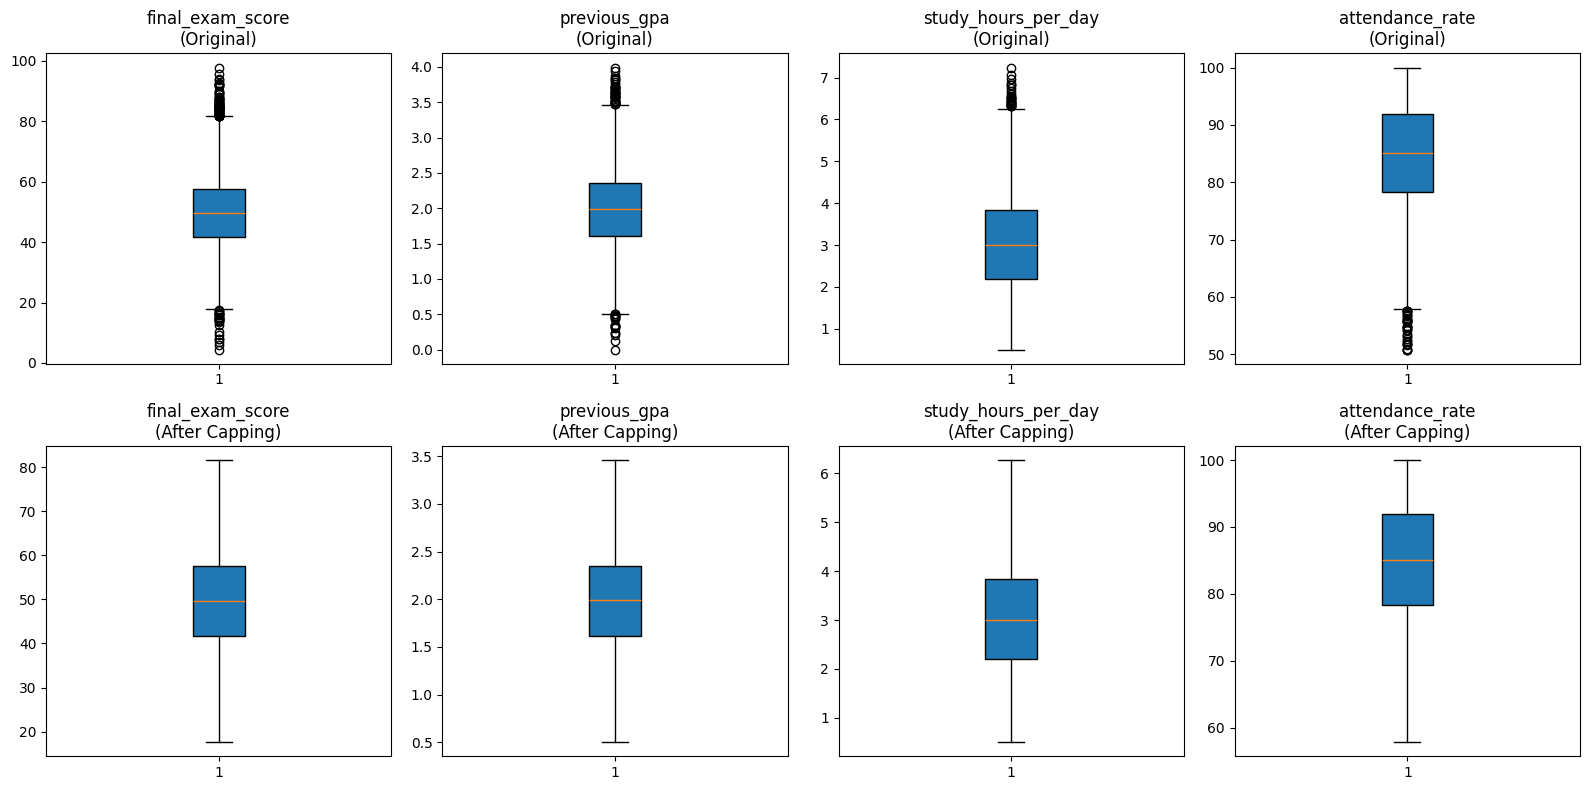

In [5]:
# Visualize before and after outlier handling
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(['final_exam_score', 'previous_gpa', 'study_hours_per_day', 'attendance_rate']):
    # Before
    axes[i].boxplot(df[col], patch_artist=True)
    axes[i].set_title(f'{col}\n(Original)')
    
    # After
    axes[i+4].boxplot(df_processed[col], patch_artist=True)
    axes[i+4].set_title(f'{col}\n(After Capping)')

plt.tight_layout()
plt.savefig('../docs/outlier_handling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### <font>2.3 Encode Categorical Variables</font>


In [6]:
# Identify categorical columns
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

# Separate by encoding type
# Binary columns -> Label Encoding
# Nominal columns -> One-Hot Encoding
# Ordinal columns -> Ordinal Encoding (manual mapping)

binary_cols = ['gender', 'internet_access', 'tutoring', 'pass_fail']
nominal_cols = ['study_environment']
ordinal_cols = ['parental_education', 'family_income', 'grade_category']

print(f"\nBinary columns (Label Encoding): {binary_cols}")
print(f"Nominal columns (One-Hot): {nominal_cols}")
print(f"Ordinal columns (Ordinal Encoding): {ordinal_cols}")

Categorical columns: ['student_id', 'gender', 'parental_education', 'family_income', 'internet_access', 'study_environment', 'tutoring', 'pass_fail', 'grade_category']

Binary columns (Label Encoding): ['gender', 'internet_access', 'tutoring', 'pass_fail']
Nominal columns (One-Hot): ['study_environment']
Ordinal columns (Ordinal Encoding): ['parental_education', 'family_income', 'grade_category']


In [7]:
# 1. Label Encoding for binary columns
label_encoders = {}

for col in binary_cols:
    le = LabelEncoder()
    df_processed[col + '_encoded'] = le.fit_transform(df_processed[col])
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

gender: {'Female': np.int64(0), 'Male': np.int64(1)}
internet_access: {'No': np.int64(0), 'Yes': np.int64(1)}
tutoring: {'No': np.int64(0), 'Yes': np.int64(1)}
pass_fail: {'Fail': np.int64(0), 'Pass': np.int64(1)}


In [8]:
# 2. Ordinal Encoding for ordinal columns
# Parental Education
education_order = {'High School': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}
df_processed['parental_education_encoded'] = df_processed['parental_education'].map(education_order)
print(f"parental_education: {education_order}")

# Family Income
income_order = {'Low': 0, 'Medium': 1, 'High': 2}
df_processed['family_income_encoded'] = df_processed['family_income'].map(income_order)
print(f"family_income: {income_order}")

# Grade Category
grade_order = {'F': 0, 'D': 1, 'C': 2, 'B': 3, 'A': 4}
df_processed['grade_category_encoded'] = df_processed['grade_category'].map(grade_order)
print(f"grade_category: {grade_order}")

parental_education: {'High School': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}
family_income: {'Low': 0, 'Medium': 1, 'High': 2}
grade_category: {'F': 0, 'D': 1, 'C': 2, 'B': 3, 'A': 4}


In [9]:
# 3. One-Hot Encoding for nominal columns
df_processed = pd.get_dummies(df_processed, columns=nominal_cols, prefix=nominal_cols, dtype=int)

print("One-Hot Encoded columns created:")
for col in nominal_cols:
    new_cols = [c for c in df_processed.columns if c.startswith(col)]
    print(f"  {col}: {new_cols}")

One-Hot Encoded columns created:
  study_environment: ['study_environment_Moderate', 'study_environment_Noisy', 'study_environment_Quiet']


In [10]:
# Display encoded columns
encoded_cols = [c for c in df_processed.columns if '_encoded' in c or any(c.startswith(col + '_') for col in nominal_cols)]
print(f"\nTotal encoded columns: {len(encoded_cols)}")
df_processed[encoded_cols].head()


Total encoded columns: 10


,gender_encoded,internet_access_encoded,tutoring_encoded,pass_fail_encoded,parental_education_encoded,family_income_encoded,grade_category_encoded,study_environment_Moderate,study_environment_Noisy,study_environment_Quiet
0,1,1,1,0,0,1,0,0,0,1
1,0,1,1,1,0,0,2,0,0,1
2,1,0,1,0,0,1,0,0,0,1
3,1,1,0,0,1,1,0,0,0,1
4,1,1,0,1,1,1,2,0,0,1
